# Notebook 3 — Geospatial Analysis: Where Customers, Sellers, and Delivery Performance Diverge

**Project:** E-Commerce Retail & Fulfillment Analytics — an Amazon Retail / Operations analog
built on the Olist Brazilian e-commerce dataset (Sep-2016 – Oct-2018).

## Where this fits in the project

Notebook 1 profiled the dataset end-to-end and Notebook 2 dissected the time dimension in
depth (including a right-censoring artifact that made mid-2018 GMV *look* like it was
declining when it wasn't). The SQL analytics catalogs already touch geography in a few
places — `sql/analytics/02_customer_rfm_cohorts.sql` Q2.6 ("customer geography": GMV and
AOV by `customer_state`) and `sql/analytics/04_seller_marketplace.sql` Q4.4/Q4.5 (same- vs.
cross-state freight, seller supply by state) and `sql/analytics/03_fulfillment_ops.sql` Q3.4
(on-time delivery rate by `customer_state`) — but each of those queries looks at geography
through a single lens (revenue *or* delivery *or* sellers) in isolation.

**This notebook puts those lenses side-by-side and adds three genuinely new analyses**:
(1) a **review-score-by-state** breakdown correlated against delivery performance, (2) an
**order-level distance-decay analysis** using haversine great-circle distance between each
customer and the seller that shipped their order, and (3) a **supply-vs-demand geography
mismatch** ("self-sufficiency ratio") that ties the seller-concentration finding from Q4.2
directly to the delivery-time and review-score patterns found here. Brazil's geography is a
reasonable proxy for the kind of regional-fulfillment-network questions an Amazon Operations
or Retail Analyst is asked daily: *which regions are underserved, why, and what would it take
to fix it?*

**Mapping approach.** The `.venv` here has `plotly` (with `kaleido` for static PNG export)
but not `geopandas`/`folium`/`shapely`, and the project has no local GeoJSON/shapefiles. All
maps in this notebook use `plotly.express.scatter_geo` with the built-in
`scope="south america"` basemap — i.e. **bubble maps**, not filled choropolygons. This is a
deliberate division of labor: Python/Jupyter is for *exploration and statistical rigor*
(this notebook), while the Tableau dashboard (built later in this project) uses Tableau's
native Brazil-state shapefiles for polished filled-choropleth maps aimed at a stakeholder
audience.

| # | Notebook | Focus |
|---|---|---|
| 1 | `01_data_profiling_and_eda.ipynb` | Profiling, missingness, univariate/bivariate/multivariate EDA |
| 2 | `02_time_series_decomposition.ipynb` | Trend/seasonality decomposition of orders & revenue |
| 3 | `03_geospatial_analysis.ipynb` (this notebook) | State/city geography — demand, delivery, satisfaction, supply-vs-demand |
| 4 | `04_hypothesis_testing.ipynb` | Formal statistical tests — delivery delay vs. review score, category/region effects |
| 5 | `05_customer_segmentation.ipynb` | RFM + K-means clustering, segment profiles |
| 6 | `06_predictive_modeling.ipynb` | Logistic regression — late-delivery & low-review risk |

## Roadmap for this notebook

1. State-Level Demand Geography (extends SQL Q2.6)
2. Delivery Performance Geography & the "Estimate Buffer" Effect (extends SQL Q3.4)
3. Review-Score Geography & Its Correlation with Delivery Performance
4. Order-Level Distance-Decay Analysis (haversine distance, seller → customer)
5. Supply-vs-Demand Geography Mismatch (extends SQL Q4.5)
6. City-Level Concentration & Density
7. Key Findings Summary

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from scipy import stats

from etl.db import get_engine

%matplotlib inline
pio.renderers.default = "png"
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

engine = get_engine()
print("Connected to:", engine.url.render_as_string(hide_password=True))

# Brazilian state codes -> full names and macro-regions (used throughout this
# notebook for readable labels and for grouping the 27 states into the 5
# official IBGE macro-regions).
BR_STATE_NAMES = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapá", "AM": "Amazonas", "BA": "Bahia",
    "CE": "Ceará", "DF": "Distrito Federal", "ES": "Espírito Santo", "GO": "Goiás",
    "MA": "Maranhão", "MT": "Mato Grosso", "MS": "Mato Grosso do Sul", "MG": "Minas Gerais",
    "PA": "Pará", "PB": "Paraíba", "PR": "Paraná", "PE": "Pernambuco", "PI": "Piauí",
    "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte", "RS": "Rio Grande do Sul",
    "RO": "Rondônia", "RR": "Roraima", "SC": "Santa Catarina", "SP": "São Paulo",
    "SE": "Sergipe", "TO": "Tocantins",
}

BR_REGION = {
    "AC": "North", "AP": "North", "AM": "North", "PA": "North", "RO": "North", "RR": "North", "TO": "North",
    "AL": "Northeast", "BA": "Northeast", "CE": "Northeast", "MA": "Northeast", "PB": "Northeast",
    "PE": "Northeast", "PI": "Northeast", "RN": "Northeast", "SE": "Northeast",
    "DF": "Central-West", "GO": "Central-West", "MS": "Central-West", "MT": "Central-West",
    "ES": "Southeast", "MG": "Southeast", "RJ": "Southeast", "SP": "Southeast",
    "PR": "South", "RS": "South", "SC": "South",
}

REGION_ORDER = ["North", "Northeast", "Central-West", "Southeast", "South"]
REGION_COLORS = dict(zip(REGION_ORDER, sns.color_palette("deep", len(REGION_ORDER)).as_hex()))

Connected to: postgresql+psycopg2://akhileshvangala@localhost:5432/olist_analytics


## 1. State-Level Demand Geography

We extend SQL Q2.6 (`sql/analytics/02_customer_rfm_cohorts.sql`) — `customer_state`,
`n_customers`, `n_orders`, `gmv`, `aov`, `pct_of_total_gmv`, `cumulative_pct_gmv` — and add
an `avg_review_score` and a state **centroid** (the mean lat/lon of every customer assigned
to that state in `dim_customer`), which lets us plot a bubble map without any external
shapefile. We also tag every state with its IBGE macro-region (`BR_REGION`), which we'll
reuse for grouping throughout the notebook.

In [2]:
state_demand = pd.read_sql("""
    SELECT
        f.customer_state,
        COUNT(DISTINCT f.customer_unique_id) AS n_customers,
        COUNT(*)                             AS n_orders,
        SUM(f.order_total_value)             AS gmv,
        AVG(f.order_total_value)             AS aov,
        AVG(f.review_score)                  AS avg_review_score
    FROM marts.fact_orders f
    WHERE f.order_status NOT IN ('canceled', 'unavailable')
    GROUP BY 1
    ORDER BY gmv DESC
""", engine)

state_centroid = pd.read_sql("""
    SELECT
        customer_state,
        AVG(customer_latitude)  AS lat,
        AVG(customer_longitude) AS lon,
        COUNT(*)                AS n_dim_customers
    FROM marts.dim_customer
    WHERE customer_latitude IS NOT NULL
    GROUP BY 1
""", engine)

state_demand = state_demand.merge(state_centroid, on="customer_state", how="left")
state_demand["state_name"] = state_demand["customer_state"].map(BR_STATE_NAMES)
state_demand["region"] = state_demand["customer_state"].map(BR_REGION)
state_demand["pct_of_total_gmv"] = 100 * state_demand["gmv"] / state_demand["gmv"].sum()
state_demand["cumulative_pct_gmv"] = state_demand["pct_of_total_gmv"].cumsum()

print(f"{len(state_demand)} states represented (of 27 total)")
print(f"Total GMV across all states: R$ {state_demand['gmv'].sum():,.2f}")
print(f"Top-5 states' share of GMV:  {state_demand.head(5)['pct_of_total_gmv'].sum():.2f}%")

cols = ["customer_state", "state_name", "region", "n_customers", "n_orders", "gmv", "aov",
        "avg_review_score", "pct_of_total_gmv", "cumulative_pct_gmv"]
state_demand[cols].head(10)

27 states represented (of 27 total)
Total GMV across all states: R$ 15,735,527.03
Top-5 states' share of GMV:  73.14%


,customer_state,state_name,region,n_customers,n_orders,gmv,aov,avg_review_score,pct_of_total_gmv,cumulative_pct_gmv
0,SP,São Paulo,Southeast,39749,41127,"5,878,132.06",142.93,4.21,37.36,37.36
1,RJ,Rio de Janeiro,Southeast,12242,12698,"2,115,667.56",166.61,3.90,13.45,50.80
2,MG,Minas Gerais,Southeast,11134,11496,"1,843,074.43",160.32,4.16,11.71,62.51
3,RS,Rio Grande do Sul,South,5234,5417,"877,290.59",161.95,4.15,5.58,68.09
4,PR,Paraná,South,4825,4983,"794,196.61",159.38,4.21,5.05,73.14
5,SC,Santa Catarina,South,3502,3600,"608,023.70",168.90,4.10,3.86,77.00
6,BA,Bahia,Northeast,3244,3344,"606,908.66",181.49,3.88,3.86,80.86
7,DF,Distrito Federal,Central-West,2058,2121,"351,327.21",165.64,4.09,2.23,83.09
8,GO,Goiás,Central-West,1934,1998,"340,544.37",170.44,4.07,2.16,85.25
9,ES,Espírito Santo,Southeast,1950,2018,"323,081.03",160.10,4.05,2.05,87.31


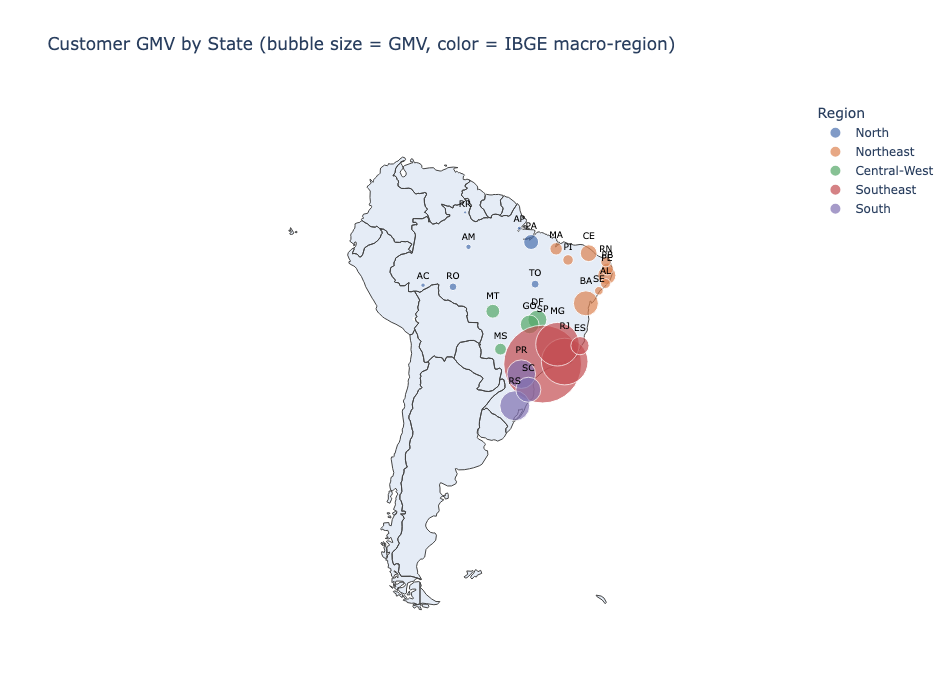

In [3]:
fig = px.scatter_geo(
    state_demand,
    lat="lat", lon="lon",
    size="gmv",
    color="region",
    category_orders={"region": REGION_ORDER},
    color_discrete_map=REGION_COLORS,
    text="customer_state",
    hover_name="state_name",
    hover_data={"gmv": ":,.0f", "n_customers": ":,", "aov": ":.2f",
                 "avg_review_score": ":.2f", "lat": False, "lon": False, "region": True},
    scope="south america",
    size_max=55,
    title="Customer GMV by State (bubble size = GMV, color = IBGE macro-region)",
)
fig.update_traces(textfont=dict(size=9, color="black"), textposition="top center")
fig.update_layout(width=950, height=700, legend=dict(title="Region"))
fig.show()

The map already tells a story: every large bubble is in the **Southeast** or **South**,
clustered within ~1,000km of São Paulo. The North (green) and parts of the Northeast
(orange) are visually almost empty — those bubbles exist but are tiny relative to SP/RJ/MG.
The next chart quantifies exactly how concentrated this is.

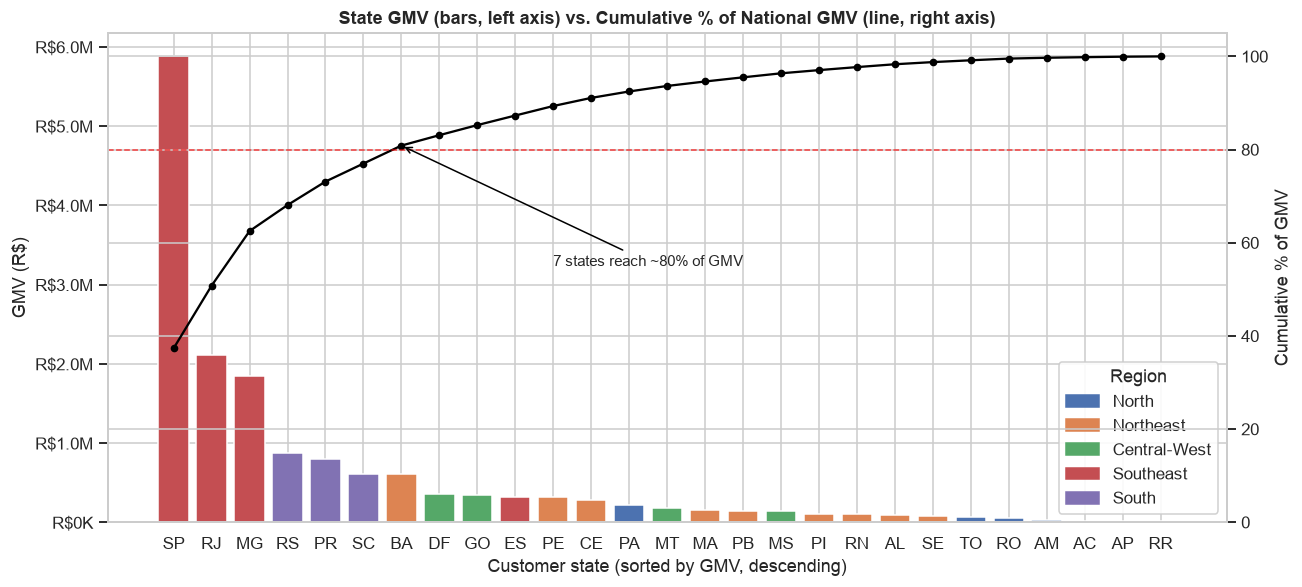

States needed to reach 80% of GMV: 7 (of 27)


In [4]:
fig, ax1 = plt.subplots(figsize=(12, 5.5))

order = state_demand.sort_values("gmv", ascending=False).reset_index(drop=True)
bar_colors = [REGION_COLORS[r] for r in order["region"]]

bars = ax1.bar(order["customer_state"], order["gmv"], color=bar_colors, edgecolor="white")
ax1.set_ylabel("GMV (R$)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M" if x >= 1e6 else f"R${x/1e3:.0f}K"))
ax1.set_title("State GMV (bars, left axis) vs. Cumulative % of National GMV (line, right axis)", fontsize=12)
ax1.set_xlabel("Customer state (sorted by GMV, descending)")

ax2 = ax1.twinx()
ax2.plot(order["customer_state"], order["cumulative_pct_gmv"], color="black", marker="o", markersize=4, linewidth=1.5)
ax2.set_ylabel("Cumulative % of GMV")
ax2.set_ylim(0, 105)
ax2.axhline(80, color="red", linestyle="--", linewidth=1, alpha=0.7)

# Legend for regions
handles = [plt.Rectangle((0, 0), 1, 1, color=REGION_COLORS[r]) for r in REGION_ORDER]
ax1.legend(handles, REGION_ORDER, title="Region", loc="lower right", framealpha=0.9)

n_states_80pct = (order["cumulative_pct_gmv"] <= 80).sum() + 1
ax2.annotate(f"{n_states_80pct} states reach ~80% of GMV",
              xy=(n_states_80pct - 1, order.loc[n_states_80pct - 1, "cumulative_pct_gmv"]),
              xytext=(n_states_80pct + 3, 55), fontsize=10,
              arrowprops=dict(arrowstyle="->", color="black"))

plt.tight_layout()
plt.show()

print(f"States needed to reach 80% of GMV: {n_states_80pct} (of {len(order)})")

### Finding: customer demand is heavily concentrated in the Southeast/South, mirroring the marketplace's seller concentration

- **São Paulo alone is 37.4% of national GMV** and **41.8% of customers** — larger than the
  next *three* states combined (RJ 13.5% + MG 11.7% + RS 5.6% = 30.8%).
- **5 of 27 states (SP, RJ, MG, RS, PR) generate 73.1% of GMV**; **7 states reach ~80%**.
  The remaining 19 states — almost the entire North and most of the Northeast — split the
  last ~20%.
- This is the *demand-side* mirror of the seller-concentration finding in Q4.2
  (`sql/analytics/04_seller_marketplace.sql`): both supply and demand are anchored in the
  Southeast, but — as Section 5 will show — **not in the same proportions**, and that gap is
  exactly what drives the delivery-performance gradient in Sections 2 and 4.

## 2. Delivery Performance Geography & the "Estimate Buffer" Effect

We extend SQL Q3.4 (`sql/analytics/03_fulfillment_ops.sql`) — on-time delivery rate by
`customer_state`, restricted to states with ≥30 delivered orders (27 of 27 states qualify) —
and add `avg_estimated_delivery_days`, which Q3.4 doesn't surface. The gap between
`avg_estimated_delivery_days` and `avg_actual_delivery_days` is the average **delivery
buffer**: how much slack Olist's SLA estimate builds in versus how long delivery actually
takes, on average, for that state.

Two related but distinct ideas are in play here, and it's worth being precise about them:

- **`avg_actual_delivery_days`** — how long delivery *actually* takes, in absolute terms.
- **`pct_late`** — how often delivery is *later than the estimate the customer was shown*.

A state can be slow in absolute terms but have a *low* `pct_late` if its estimates are
generously padded — and vice versa. We'll see both patterns below.

In [5]:
state_delivery = pd.read_sql("""
    SELECT
        customer_state,
        COUNT(*)                                                     AS n_delivered,
        SUM(CASE WHEN is_late THEN 1 ELSE 0 END)                     AS n_late,
        100.0 * SUM(CASE WHEN is_late THEN 1 ELSE 0 END) / COUNT(*)  AS pct_late,
        AVG(actual_delivery_days)                                    AS avg_actual_delivery_days,
        AVG(delivery_delay_days)                                     AS avg_delay_days,
        AVG(estimated_delivery_days)                                 AS avg_estimated_delivery_days
    FROM marts.fact_orders
    WHERE is_delivered = TRUE
    GROUP BY 1
    HAVING COUNT(*) >= 30
    ORDER BY pct_late DESC
""", engine)

state_delivery["state_name"] = state_delivery["customer_state"].map(BR_STATE_NAMES)
state_delivery["region"] = state_delivery["customer_state"].map(BR_REGION)
state_delivery["avg_buffer_days"] = -state_delivery["avg_delay_days"]  # positive = delivered before estimate, on average

print(f"States qualifying (>=30 delivered orders): {len(state_delivery)} / 27")
print(f"\npct_late range: {state_delivery['pct_late'].min():.2f}% ({state_delivery.loc[state_delivery['pct_late'].idxmin(), 'customer_state']}) "
      f"to {state_delivery['pct_late'].max():.2f}% ({state_delivery.loc[state_delivery['pct_late'].idxmax(), 'customer_state']})")
print(f"avg_actual_delivery_days range: {state_delivery['avg_actual_delivery_days'].min():.1f} days ({state_delivery.loc[state_delivery['avg_actual_delivery_days'].idxmin(), 'customer_state']}) "
      f"to {state_delivery['avg_actual_delivery_days'].max():.1f} days ({state_delivery.loc[state_delivery['avg_actual_delivery_days'].idxmax(), 'customer_state']})")

state_delivery[["customer_state", "state_name", "region", "n_delivered", "pct_late",
                "avg_actual_delivery_days", "avg_estimated_delivery_days", "avg_buffer_days"]].head(10)

States qualifying (>=30 delivered orders): 27 / 27

pct_late range: 2.88% (RO) to 23.93% (AL)
avg_actual_delivery_days range: 8.8 days (SP) to 29.4 days (RR)


,customer_state,state_name,region,n_delivered,pct_late,avg_actual_delivery_days,avg_estimated_delivery_days,avg_buffer_days
0,AL,Alagoas,Northeast,397,23.93,24.54,32.58,8.03
1,MA,Maranhão,Northeast,717,19.67,21.57,30.46,8.89
2,PI,Piauí,Northeast,476,15.97,19.46,30.09,10.63
3,CE,Ceará,Northeast,1279,15.32,21.27,31.38,10.11
4,SE,Sergipe,Northeast,335,15.22,21.52,30.85,9.33
5,BA,Bahia,Northeast,3256,14.04,19.34,29.43,10.10
6,RJ,Rio de Janeiro,Southeast,12350,13.47,15.31,26.36,11.05
7,TO,Tocantins,North,274,12.77,17.66,29.10,11.44
8,PA,Pará,North,946,12.37,23.77,37.16,13.39
9,ES,Espírito Santo,Southeast,1995,12.23,15.79,25.59,9.80


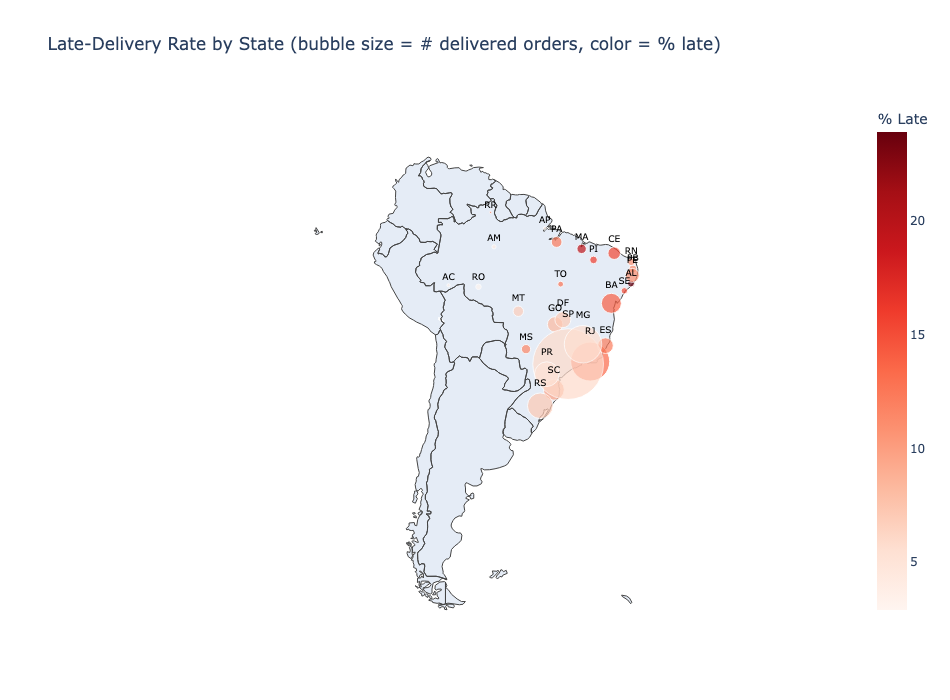

In [6]:
map_df = state_delivery.merge(state_demand[["customer_state", "lat", "lon"]], on="customer_state")

fig = px.scatter_geo(
    map_df,
    lat="lat", lon="lon",
    size="n_delivered",
    color="pct_late",
    color_continuous_scale="Reds",
    text="customer_state",
    hover_name="state_name",
    hover_data={"pct_late": ":.2f", "avg_actual_delivery_days": ":.1f",
                 "avg_estimated_delivery_days": ":.1f", "lat": False, "lon": False},
    scope="south america",
    size_max=50,
    title="Late-Delivery Rate by State (bubble size = # delivered orders, color = % late)",
)
fig.update_traces(textfont=dict(size=9, color="black"), textposition="top center")
fig.update_layout(width=950, height=700, coloraxis_colorbar=dict(title="% Late"))
fig.show()

The reddest bubbles cluster in the **Northeast** (AL, MA, PI, CE, SE, BA) plus **PA**
in the North — all far from the Southeast seller hub. But absolute distance can't be the
whole story, because the *most remote* states (AC, AP, AM, RO — deep North) are some of the
*lightest*-colored bubbles on the map despite having the longest absolute delivery times in
the country (Section 1's centroid table). The next chart resolves this apparent
contradiction.

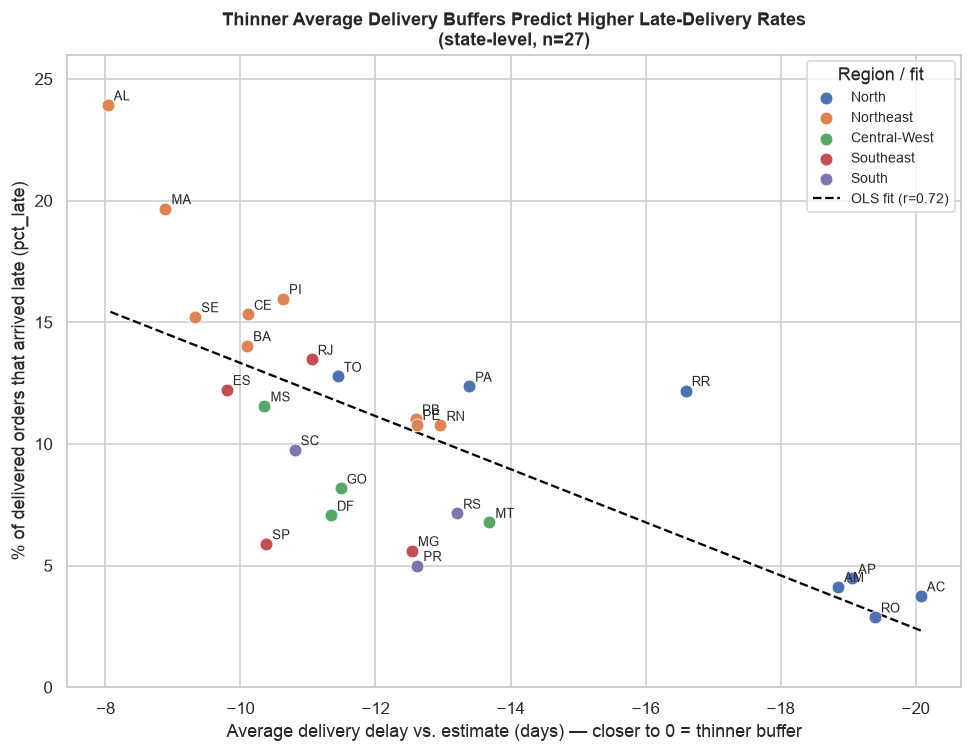

Correlation (avg_delay_days vs pct_late): r = 0.715, p = 2.76e-05
Correlation (avg_estimated_delivery_days vs pct_late): r = -0.145
Correlation (avg_actual_delivery_days vs pct_late): r = 0.281


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

for region in REGION_ORDER:
    sub = state_delivery[state_delivery["region"] == region]
    ax.scatter(sub["avg_delay_days"], sub["pct_late"], s=70, color=REGION_COLORS[region],
               label=region, edgecolor="white", linewidth=0.5, zorder=3)

for _, row in state_delivery.iterrows():
    ax.annotate(row["customer_state"], (row["avg_delay_days"], row["pct_late"]),
                xytext=(4, 3), textcoords="offset points", fontsize=8.5)

# Regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(state_delivery["avg_delay_days"], state_delivery["pct_late"])
xs = np.linspace(state_delivery["avg_delay_days"].min(), state_delivery["avg_delay_days"].max(), 50)
ax.plot(xs, slope * xs + intercept, color="black", linestyle="--", linewidth=1.5, zorder=2,
        label=f"OLS fit (r={r_value:.2f})")

ax.set_xlabel("Average delivery delay vs. estimate (days) — closer to 0 = thinner buffer")
ax.set_ylabel("% of delivered orders that arrived late (pct_late)")
ax.set_title("Thinner Average Delivery Buffers Predict Higher Late-Delivery Rates\n(state-level, n=27)")
ax.set_ylim(0, 26)  # headroom so the AL label (top point) isn't clipped
ax.invert_xaxis()  # so "thin buffer" (near 0) is on the right, matching the upward risk trend visually
ax.legend(title="Region / fit", loc="upper right", fontsize=9)  # upper-right is empty post-inversion (AL sits at upper-left)

plt.tight_layout()
plt.show()

print(f"Correlation (avg_delay_days vs pct_late): r = {r_value:.3f}, p = {p_value:.2e}")
print(f"Correlation (avg_estimated_delivery_days vs pct_late): r = {state_delivery['avg_estimated_delivery_days'].corr(state_delivery['pct_late']):.3f}")
print(f"Correlation (avg_actual_delivery_days vs pct_late): r = {state_delivery['avg_actual_delivery_days'].corr(state_delivery['pct_late']):.3f}")

### Finding: the SLA estimate's "buffer" — not absolute delivery time — drives late-delivery risk by state

- Every state's *average* `delivery_delay_days` is negative (orders arrive before the
  estimate on average, everywhere) — but the **size of that average buffer varies from
  -8 days (AL) to -20 days (AC)**, and **`pct_late` tracks the buffer size almost linearly
  (r=0.72, p<0.0001)**.
- **AL (Alagoas)** has both the thinnest average buffer (-8.0 days) and the highest
  `pct_late` (23.9%) in the country — nearly 1-in-4 deliveries miss the promised date.
  MA, SE, BA, CE round out a Northeast cluster all with buffers ≤-10 days and `pct_late`
  ≥14%.
- By contrast, the deep-North states (**AC, AP, AM, RO**) have the *longest absolute*
  delivery times (19-29 days) in the country, **but the *lowest* `pct_late` (2.9-4.5%)** —
  because their estimated-delivery windows are even longer still (38-46 days), giving a
  -16 to -20 day buffer. Olist's SLA model evidently *does* account for these routes being
  slow — it just doesn't account for it *enough* in the Northeast cluster relative to the
  variance those routes actually see.
- **Operational read:** `pct_late` is a measure of *promise-keeping*, not speed. A region
  can be "slow but reliable" (deep North) or "moderately fast but unreliable" (Northeast).
  For a CX/ops team, the Northeast cluster is the higher-priority fix — not because parcels
  arrive late in absolute terms, but because the *promise itself* is being broken at a
  much higher rate, which Section 3 will show has a measurable satisfaction cost.

## 3. Review-Score Geography & Its Correlation with Delivery Performance

This is a new analysis (not in the SQL catalog): review-score statistics by
`customer_state`, restricted to states with ≥30 reviews, merged with Section 2's delivery
metrics so we can correlate them directly.

In [8]:
state_reviews = pd.read_sql("""
    SELECT
        customer_state,
        COUNT(*)                                                              AS n_reviews,
        AVG(review_score)                                                     AS avg_review_score,
        100.0 * SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) / COUNT(*) AS pct_low_score,
        100.0 * SUM(CASE WHEN review_score = 5 THEN 1 ELSE 0 END) / COUNT(*)  AS pct_five_star
    FROM marts.fact_orders
    WHERE has_review AND order_status NOT IN ('canceled', 'unavailable')
    GROUP BY 1
    HAVING COUNT(*) >= 30
    ORDER BY avg_review_score ASC
""", engine)

state_reviews["state_name"] = state_reviews["customer_state"].map(BR_STATE_NAMES)
state_reviews["region"] = state_reviews["customer_state"].map(BR_REGION)

merged_dr = state_delivery.merge(state_reviews, on=["customer_state", "state_name", "region"])

print("Worst 5 states by avg_review_score:")
print(state_reviews[["customer_state", "state_name", "n_reviews", "avg_review_score", "pct_low_score", "pct_five_star"]].head(5).to_string(index=False))
print("\nBest 5 states by avg_review_score:")
print(state_reviews[["customer_state", "state_name", "n_reviews", "avg_review_score", "pct_low_score", "pct_five_star"]].tail(5).to_string(index=False))

corr_cols = ["pct_late", "avg_actual_delivery_days", "avg_buffer_days", "avg_review_score", "pct_low_score"]
print("\nCorrelation matrix (state-level, n=27):")
print(merged_dr[corr_cols].corr().round(3).to_string())

Worst 5 states by avg_review_score:
customer_state state_name  n_reviews  avg_review_score  pct_low_score  pct_five_star
            RR    Roraima         45              3.64          22.22          44.44
            AL    Alagoas        408              3.76          23.77          48.04
            MA   Maranhão        731              3.78          21.34          47.61
            SE    Sergipe        344              3.84          20.93          51.16
            PA       Pará        956              3.86          19.25          50.21

Best 5 states by avg_review_score:
customer_state   state_name  n_reviews  avg_review_score  pct_low_score  pct_five_star
            MG Minas Gerais      11422              4.16          12.50          59.46
            AP        Amapá         67              4.19           7.46          50.75
            SP    São Paulo      40868              4.21          11.62          61.03
            PR       Paraná       4957              4.21          11.6

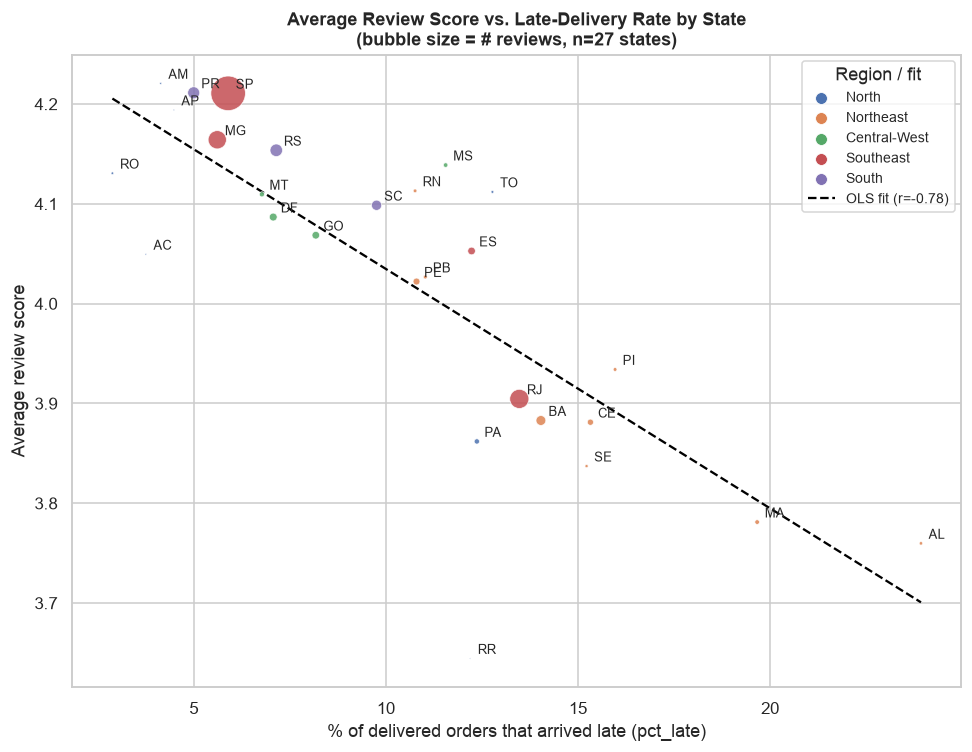

Correlation (pct_late vs avg_review_score): r = -0.785, p = 1.27e-06

RJ: pct_late=13.47%, avg_review_score=3.90, n_reviews=12,540
SP: pct_late=5.89%, avg_review_score=4.21, n_reviews=40,868


In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

for region in REGION_ORDER:
    sub = merged_dr[merged_dr["region"] == region]
    ax.scatter(sub["pct_late"], sub["avg_review_score"], s=sub["n_reviews"] / 80,
               color=REGION_COLORS[region], edgecolor="white", linewidth=0.5,
               alpha=0.85, zorder=3)

for _, row in merged_dr.iterrows():
    ax.annotate(row["customer_state"], (row["pct_late"], row["avg_review_score"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8.5)

slope, intercept, r_value, p_value, std_err = stats.linregress(merged_dr["pct_late"], merged_dr["avg_review_score"])
xs = np.linspace(merged_dr["pct_late"].min(), merged_dr["pct_late"].max(), 50)
ols_line, = ax.plot(xs, slope * xs + intercept, color="black", linestyle="--", linewidth=1.5, zorder=2)

ax.set_xlabel("% of delivered orders that arrived late (pct_late)")
ax.set_ylabel("Average review score")
ax.set_title("Average Review Score vs. Late-Delivery Rate by State\n(bubble size = # reviews, n=27 states)")

# Manual legend handles with a fixed marker size (the real scatter markers are
# sized by n_reviews, which would otherwise produce wildly inconsistent legend
# glyphs per region).
region_handles = [ax.scatter([], [], s=60, color=REGION_COLORS[r], edgecolor="white", linewidth=0.5) for r in REGION_ORDER]
ax.legend(region_handles + [ols_line], REGION_ORDER + [f"OLS fit (r={r_value:.2f})"],
          title="Region / fit", loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Correlation (pct_late vs avg_review_score): r = {r_value:.3f}, p = {p_value:.2e}")

# RJ as a labeled outlier check
rj = merged_dr[merged_dr["customer_state"] == "RJ"].iloc[0]
sp = merged_dr[merged_dr["customer_state"] == "SP"].iloc[0]
print(f"\nRJ: pct_late={rj['pct_late']:.2f}%, avg_review_score={rj['avg_review_score']:.2f}, n_reviews={rj['n_reviews']:,.0f}")
print(f"SP: pct_late={sp['pct_late']:.2f}%, avg_review_score={sp['avg_review_score']:.2f}, n_reviews={sp['n_reviews']:,.0f}")

### Finding: review scores track *promise-keeping* (pct_late), not absolute delivery speed — and RJ is the most consequential outlier

- **`avg_review_score` correlates with `pct_late` at r=-0.79** (p<0.0001) — much more
  strongly than with `avg_actual_delivery_days` (r=-0.53) or `avg_buffer_days` (r=+0.50).
  Statistically, *being told an accurate date and missing it* hurts satisfaction more than
  *the trip simply taking a while*.
- **RJ (Rio de Janeiro)** is the state to watch: it's the **2nd-largest market by GMV**
  (13.5% of national GMV, 12,540 reviews — second only to SP's 40,868), sits relatively
  close to the SP seller hub, yet has a **below-median `avg_review_score` (3.90)** driven by
  a **`pct_late` of 13.5%** — more than double SP's 5.9% despite similar geography. At SP's
  scale, RJ's review-score gap alone represents tens of thousands of orders rated lower than
  they would be under SP-like reliability.
- **Small-state outliers** (RR, AP, AM with n<150 reviews) should be read with caution — a
  handful of bad reviews swing their averages a lot — but the **large-state pattern (SP, RJ,
  MG, BA, PR, RS — all n>3,000)** is robust and is exactly the pattern the regression line
  captures.
- **Operational read:** if forced to pick ONE state for a fulfillment-reliability
  intervention by ROI, **RJ outranks the Northeast cluster** on pure volume — a 1-point
  `pct_late` improvement in RJ affects ~10x as many orders as the same improvement in AL.

## 4. Order-Level Distance-Decay Analysis (Haversine Distance)

Sections 1-3 worked at the state level. Here we go to the **order level**: for every
*single-seller* delivered order, we compute the **great-circle (haversine) distance** in km
between the customer's location (`dim_customer.customer_latitude/longitude`) and the
shipping seller's location (`dim_seller.seller_latitude/longitude`, joined via
`fact_order_items` for `order_item_id = 1`). We restrict to `n_distinct_sellers = 1` so the
"seller location" for an order is unambiguous — this still covers **98.2% of all delivered
orders**.

This is the most granular geography question in the notebook: *does shipping distance,
measured directly rather than via state-level proxies, predict delivery time, freight cost,
lateness, and satisfaction — and how much of the state-level pattern from Sections 2-3 does
it explain?*

In [10]:
order_geo = pd.read_sql("""
    SELECT
        f.order_id,
        f.customer_state,
        dc.customer_latitude,
        dc.customer_longitude,
        ds.seller_state,
        ds.seller_latitude,
        ds.seller_longitude,
        f.actual_delivery_days,
        f.delivery_delay_days,
        f.is_late,
        f.review_score,
        f.freight_value_total,
        f.order_total_value
    FROM marts.fact_orders f
    JOIN marts.dim_customer dc ON dc.customer_unique_id = f.customer_unique_id
    JOIN marts.fact_order_items foi ON foi.order_id = f.order_id AND foi.order_item_id = 1
    JOIN marts.dim_seller ds ON ds.seller_id = foi.seller_id
    WHERE f.order_status = 'delivered'
      AND f.n_distinct_sellers = 1
      AND dc.customer_latitude IS NOT NULL
      AND ds.seller_latitude IS NOT NULL
""", engine)

n_all_delivered = pd.read_sql("SELECT COUNT(*) AS n FROM marts.fact_orders WHERE order_status = \'delivered\'", engine)["n"][0]
print(f"order_geo rows: {len(order_geo):,} ({100 * len(order_geo) / n_all_delivered:.1f}% of all {n_all_delivered:,} delivered orders)")


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance between two (lat, lon) points in kilometers."""
    R = 6371.0
    lat1r, lon1r, lat2r, lon2r = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))


order_geo["distance_km"] = haversine_km(
    order_geo["customer_latitude"], order_geo["customer_longitude"],
    order_geo["seller_latitude"], order_geo["seller_longitude"]
)
order_geo["same_state"] = order_geo["customer_state"] == order_geo["seller_state"]

order_geo["distance_km"].describe().round(1)

order_geo rows: 94,734 (98.2% of all 96,478 delivered orders)


count   94,734.00
mean       601.40
std        594.90
min          0.00
25%        185.10
50%        433.90
75%        799.30
max      8,677.90
Name: distance_km, dtype: float64

In [11]:
bins = [0, 10, 100, 300, 600, 1000, 1500, 2000, 5000]
labels = ["0-10", "10-100", "100-300", "300-600", "600-1000", "1000-1500", "1500-2000", "2000+"]
order_geo["distance_bucket"] = pd.cut(order_geo["distance_km"], bins=bins, labels=labels)

bucket_summary = order_geo.groupby("distance_bucket", observed=True).agg(
    n_orders=("order_id", "count"),
    avg_distance_km=("distance_km", "mean"),
    avg_actual_delivery_days=("actual_delivery_days", "mean"),
    avg_delay_days=("delivery_delay_days", "mean"),
    pct_late=("is_late", "mean"),
    avg_freight=("freight_value_total", "mean"),
    avg_order_value=("order_total_value", "mean"),
    avg_review_score=("review_score", "mean"),
).reset_index()
bucket_summary["pct_late"] = 100 * bucket_summary["pct_late"]
bucket_summary["freight_pct_of_order"] = 100 * bucket_summary["avg_freight"] / bucket_summary["avg_order_value"]

bucket_summary

,distance_bucket,n_orders,avg_distance_km,avg_actual_delivery_days,avg_delay_days,pct_late,avg_freight,avg_order_value,avg_review_score,freight_pct_of_order
0,0-10,2296,6.17,5.74,-8.88,5.79,12.91,123.46,4.37,10.45
1,10-100,15376,45.13,6.65,-8.75,6.55,13.30,126.74,4.27,10.50
2,100-300,13153,200.30,10.04,-10.74,6.51,18.41,149.30,4.27,12.33
3,300-600,31042,429.98,12.67,-11.63,7.84,22.06,154.69,4.15,14.26
4,600-1000,17652,784.82,14.76,-12.07,8.54,24.44,163.01,4.14,14.99
5,1000-1500,6488,"1,234.31",17.34,-12.03,10.30,29.41,196.46,4.07,14.97
6,1500-2000,3132,"1,754.84",19.47,-12.14,12.23,39.46,216.34,4.07,18.24
7,2000+,5569,"2,317.39",21.20,-11.96,13.74,39.52,213.70,3.99,18.49


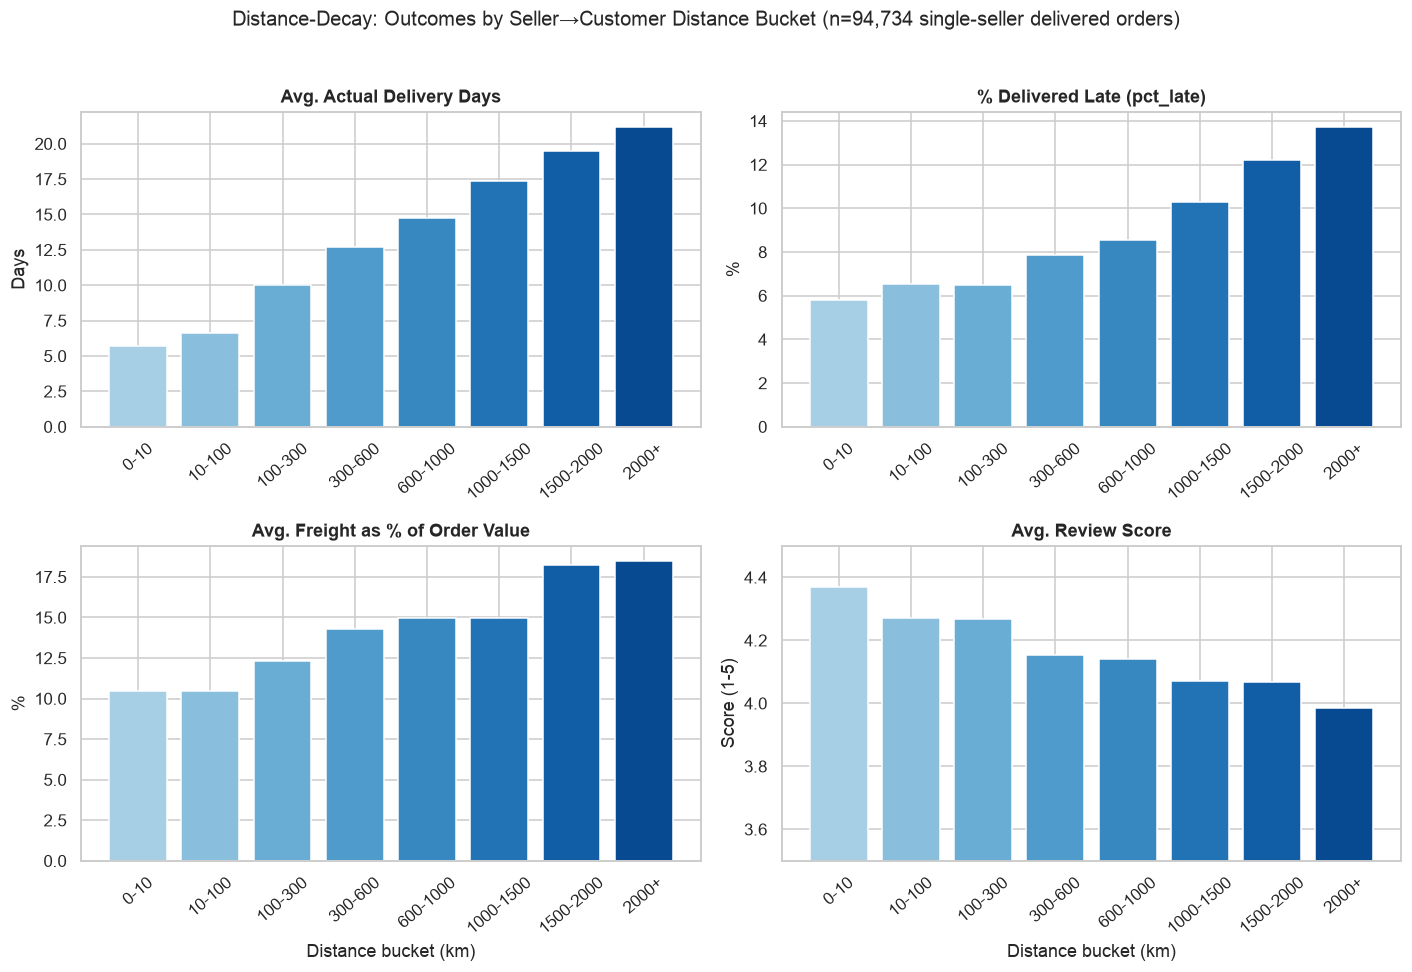

Order-level correlations with distance_km:
  distance_km vs actual_delivery_days  : r = +0.3933  (n=94,726)
  distance_km vs delivery_delay_days   : r = -0.0749  (n=94,726)
  distance_km vs freight_value_total   : r = +0.3197  (n=94,734)
  distance_km vs review_score          : r = -0.0609  (n=94,103)


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
x = bucket_summary["distance_bucket"].astype(str)
cmap_vals = np.linspace(0.35, 0.9, len(x))
bar_colors = [plt.cm.Blues(v) for v in cmap_vals]

ax = axes[0, 0]
ax.bar(x, bucket_summary["avg_actual_delivery_days"], color=bar_colors, edgecolor="white")
ax.set_title("Avg. Actual Delivery Days")
ax.set_ylabel("Days")
ax.tick_params(axis="x", rotation=40)

ax = axes[0, 1]
ax.bar(x, bucket_summary["pct_late"], color=bar_colors, edgecolor="white")
ax.set_title("% Delivered Late (pct_late)")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=40)

ax = axes[1, 0]
ax.bar(x, bucket_summary["freight_pct_of_order"], color=bar_colors, edgecolor="white")
ax.set_title("Avg. Freight as % of Order Value")
ax.set_ylabel("%")
ax.set_xlabel("Distance bucket (km)")
ax.tick_params(axis="x", rotation=40)

ax = axes[1, 1]
ax.bar(x, bucket_summary["avg_review_score"], color=bar_colors, edgecolor="white")
ax.set_title("Avg. Review Score")
ax.set_ylabel("Score (1-5)")
ax.set_xlabel("Distance bucket (km)")
ax.set_ylim(3.5, 4.5)
ax.tick_params(axis="x", rotation=40)

fig.suptitle(f"Distance-Decay: Outcomes by Seller→Customer Distance Bucket (n={len(order_geo):,} single-seller delivered orders)", fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

print("Order-level correlations with distance_km:")
for col, label in [("actual_delivery_days", "actual_delivery_days"),
                    ("delivery_delay_days", "delivery_delay_days"),
                    ("freight_value_total", "freight_value_total"),
                    ("review_score", "review_score")]:
    valid = order_geo[["distance_km", col]].dropna()
    r = valid["distance_km"].corr(valid[col])
    print(f"  distance_km vs {label:22s}: r = {r:+.4f}  (n={len(valid):,})")

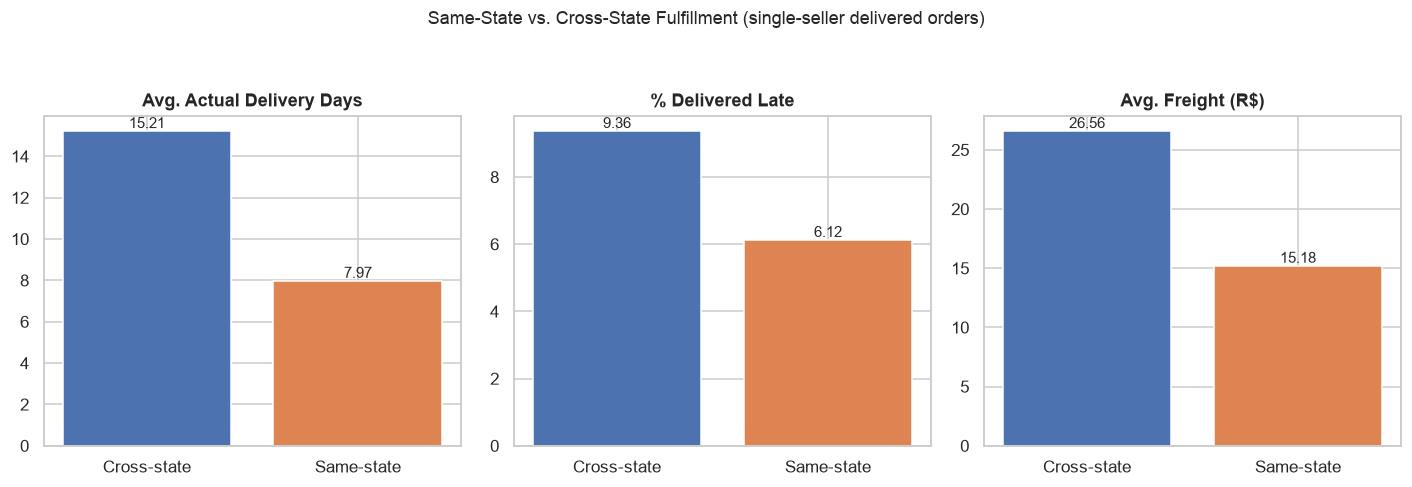

,group,n_orders,pct_of_orders,avg_distance_km,avg_actual_delivery_days,pct_late,avg_freight
0,Cross-state,60555,63.92,854.36,15.21,9.36,26.56
1,Same-state,34179,36.08,153.23,7.97,6.12,15.18


In [13]:
same_cross = order_geo.groupby("same_state", observed=True).agg(
    n_orders=("order_id", "count"),
    avg_distance_km=("distance_km", "mean"),
    avg_actual_delivery_days=("actual_delivery_days", "mean"),
    pct_late=("is_late", "mean"),
    avg_freight=("freight_value_total", "mean"),
).reset_index()
same_cross["pct_late"] = 100 * same_cross["pct_late"]
same_cross["group"] = same_cross["same_state"].map({True: "Same-state", False: "Cross-state"})
same_cross["pct_of_orders"] = 100 * same_cross["n_orders"] / same_cross["n_orders"].sum()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
metrics = [("avg_actual_delivery_days", "Avg. Actual Delivery Days"),
           ("pct_late", "% Delivered Late"),
           ("avg_freight", "Avg. Freight (R$)")]
colors = ["#4C72B0", "#DD8452"]

for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(same_cross["group"], same_cross[col], color=colors, edgecolor="white")
    ax.set_title(title)
    for bar, val in zip(bars, same_cross[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:,.2f}", ha="center", va="bottom", fontsize=10)

fig.suptitle("Same-State vs. Cross-State Fulfillment (single-seller delivered orders)", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

same_cross[["group", "n_orders", "pct_of_orders", "avg_distance_km", "avg_actual_delivery_days", "pct_late", "avg_freight"]]

### Finding: distance-decay is real, monotonic, and roughly doubles every outcome from "local" to "2000km+" — but the SLA estimate absorbs most of the *delay* effect

- Across the 8 distance buckets (0-10km to 2000km+), **`avg_actual_delivery_days` rises
  3.7x** (5.7 → 21.2 days), **freight as a share of order value rises from 10.5% to
  18.5%**, **`pct_late` more than doubles** (5.8% → 13.7%), and **`avg_review_score`
  declines steadily and never increases** across the 8 buckets (4.37 → 3.99) — the
  cleanest dose-response relationship in the whole notebook.
- Yet **order-level `distance_km` correlates only weakly with `delivery_delay_days`**
  (r=-0.07) despite correlating moderately with `actual_delivery_days` (r=+0.39) — i.e.
  Olist's `estimated_delivery_days` scales with distance too, so the *delay-vs-promise*
  signal is mostly distance-independent. This reconciles with Section 2: distance drives
  absolute time, but the **buffer-thinness** pattern (which varies by state for reasons
  other than pure distance — likely carrier network density) drives `pct_late`.
- **64% of single-seller orders (60,555 / 94,734) are fulfilled cross-state**, and those
  orders take **~1.9x longer** (15.2 vs. 8.0 days) and cost **~75% more in freight** (R$26.56
  vs. R$15.18) than same-state orders. Given Section 1's finding that demand is spread
  across 27 states while Section 5 will show supply is even *more* concentrated, cross-state
  fulfillment isn't an edge case — **it's the majority case**, and it is measurably more
  expensive and slower for the customer on both delivery time and satisfaction.

## 5. Supply-vs-Demand Geography Mismatch (extends SQL Q4.5)

`sql/analytics/04_seller_marketplace.sql` Q4.5 looks at same- vs. cross-state freight from
the seller's perspective. Here we build the complementary **state-level supply-vs-demand
balance**: for every state, what share of *national demand* (customer GMV) does it
represent vs. what share of *national supply* (seller item revenue, via
`fact_order_items` joined to `dim_seller.seller_state`)? The ratio of these two shares — the
**self-sufficiency ratio** — says whether a state is a net *exporter* (ratio > 1, its
sellers sell more than its customers buy) or net *importer* (ratio < 1).

In [14]:
demand = pd.read_sql("""
    SELECT customer_state AS state, SUM(order_total_value) AS demand_gmv
    FROM marts.fact_orders
    WHERE order_status NOT IN ('canceled', 'unavailable')
    GROUP BY 1
""", engine)

supply = pd.read_sql("""
    SELECT ds.seller_state AS state, SUM(foi.item_total_value) AS supply_revenue,
           COUNT(DISTINCT ds.seller_id) AS n_sellers
    FROM marts.fact_order_items foi
    JOIN marts.dim_seller ds ON ds.seller_id = foi.seller_id
    JOIN marts.fact_orders f ON f.order_id = foi.order_id
    WHERE f.order_status NOT IN ('canceled', 'unavailable')
    GROUP BY 1
""", engine)

supply_demand = demand.merge(supply, on="state", how="outer")
supply_demand["supply_revenue"] = supply_demand["supply_revenue"].fillna(0)
supply_demand["n_sellers"] = supply_demand["n_sellers"].fillna(0).astype(int)
supply_demand["demand_share_pct"] = 100 * supply_demand["demand_gmv"] / supply_demand["demand_gmv"].sum()
supply_demand["supply_share_pct"] = 100 * supply_demand["supply_revenue"] / supply_demand["supply_revenue"].sum()
supply_demand["self_sufficiency_ratio"] = supply_demand["supply_share_pct"] / supply_demand["demand_share_pct"]
supply_demand["state_name"] = supply_demand["state"].map(BR_STATE_NAMES)
supply_demand["region"] = supply_demand["state"].map(BR_REGION)
supply_demand = supply_demand.sort_values("demand_gmv", ascending=False).reset_index(drop=True)

n_no_sellers = (supply_demand["n_sellers"] == 0).sum()
print(f"States with >=1 local seller: {(supply_demand['n_sellers'] > 0).sum()} / {len(supply_demand)}")
print(f"States with ZERO local sellers (100% import-dependent): {n_no_sellers}")
print(supply_demand.loc[supply_demand["n_sellers"] == 0, ["state", "state_name", "demand_share_pct"]].to_string(index=False))

supply_demand[["state", "state_name", "region", "n_sellers", "demand_share_pct", "supply_share_pct", "self_sufficiency_ratio"]].head(10)

States with >=1 local seller: 23 / 27
States with ZERO local sellers (100% import-dependent): 4
state state_name  demand_share_pct
   AL    Alagoas              0.61
   TO  Tocantins              0.39
   AP      Amapá              0.10
   RR    Roraima              0.06


,state,state_name,region,n_sellers,demand_share_pct,supply_share_pct,self_sufficiency_ratio
0,SP,São Paulo,Southeast,1822,37.36,64.59,1.73
1,RJ,Rio de Janeiro,Southeast,170,13.45,5.92,0.44
2,MG,Minas Gerais,Southeast,240,11.71,7.71,0.66
3,RS,Rio Grande do Sul,South,129,5.58,2.76,0.50
4,PR,Paraná,South,344,5.05,9.23,1.83
5,SC,Santa Catarina,South,186,3.86,4.64,1.20
6,BA,Bahia,Northeast,19,3.86,1.94,0.50
7,DF,Distrito Federal,Central-West,30,2.23,0.73,0.33
8,GO,Goiás,Central-West,40,2.16,0.50,0.23
9,ES,Espírito Santo,Southeast,23,2.05,0.38,0.19


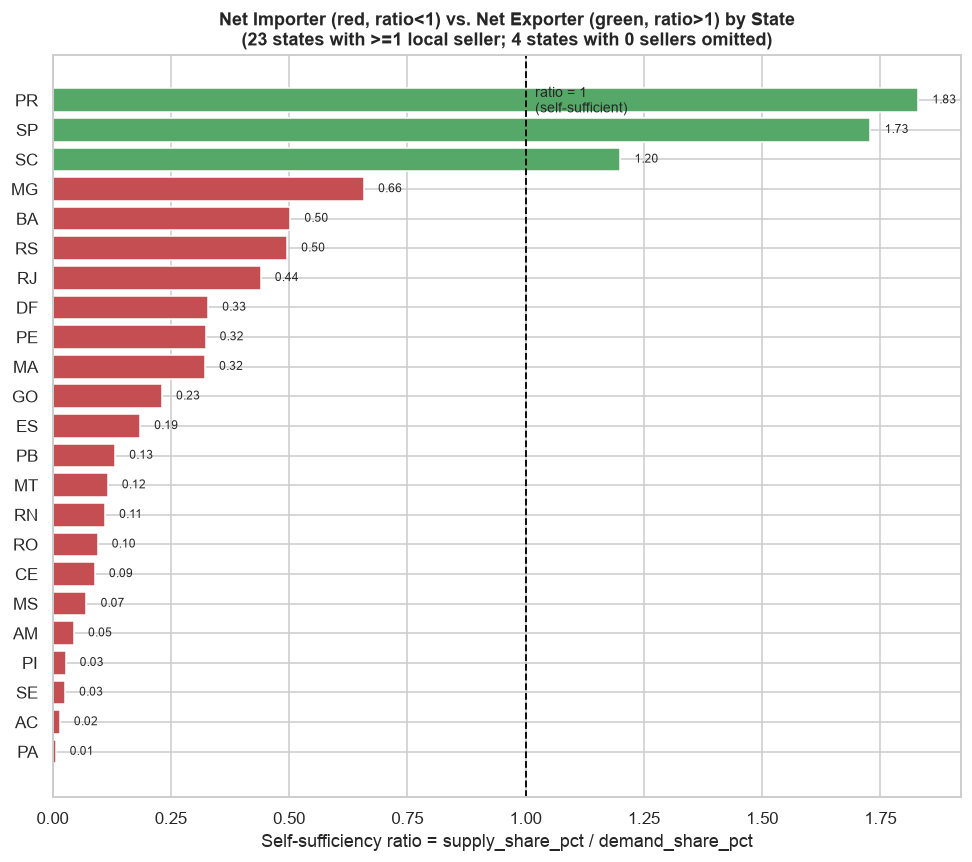

SP: demand_share=37.36%, supply_share=64.59%, ratio=1.73


In [15]:
has_sellers = supply_demand[supply_demand["n_sellers"] > 0].sort_values("self_sufficiency_ratio", ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#C44E52" if r < 1 else "#55A868" for r in has_sellers["self_sufficiency_ratio"]]
bars = ax.barh(has_sellers["state"], has_sellers["self_sufficiency_ratio"], color=colors, edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2)
ax.text(1.02, len(has_sellers) - 0.5, "ratio = 1\n(self-sufficient)", fontsize=9, va="top")
ax.set_xlabel("Self-sufficiency ratio = supply_share_pct / demand_share_pct")
ax.set_title(f"Net Importer (red, ratio<1) vs. Net Exporter (green, ratio>1) by State\n({len(has_sellers)} states with >=1 local seller; {n_no_sellers} states with 0 sellers omitted)")

for bar, val in zip(bars, has_sellers["self_sufficiency_ratio"]):
    ax.text(val + (0.03 if val >= 0 else -0.03), bar.get_y() + bar.get_height() / 2, f"{val:.2f}",
            va="center", ha="left" if val >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.show()

sp_row = supply_demand[supply_demand["state"] == "SP"].iloc[0]
print(f"SP: demand_share={sp_row['demand_share_pct']:.2f}%, supply_share={sp_row['supply_share_pct']:.2f}%, ratio={sp_row['self_sufficiency_ratio']:.2f}")

### Finding: seller supply is even more concentrated than customer demand — and 4 states have zero local sellers

- **SP supplies 64.6% of all marketplace item revenue but consumes only 37.4%** — a
  self-sufficiency ratio of **1.73**, making it by far the dominant net exporter. **PR
  (1.83)** and **SC (1.20)** are the only other meaningful net exporters.
- **Every other major demand state is a net importer**: RJ (0.44), MG (0.66), BA (0.50), and
  especially **GO (0.23), ES (0.19), DF (0.33)** — these states buy far more than their local
  sellers produce, meaning the *majority* of their orders must travel cross-state (consistent
  with Section 4's finding that cross-state orders are slower and costlier).
- **4 of 27 states have zero local sellers** and are **100% dependent on cross-state /
  cross-region shipping** for every single order. This is the structural root cause behind
  the long-distance buckets in Section 4 and the high-`pct_late` Northeast cluster in
  Section 2 — those regions are not just *far* from the seller hub, **they have no
  alternative**.
- **Strategic read (Amazon-relevant):** this is precisely the kind of finding that motivates
  *regional fulfillment center* investment — concentrating supply exactly where demand is
  most under-served by local supply (GO, ES, DF, and the Northeast/North states with zero
  local sellers) would simultaneously cut the cross-state-shipping penalty (Section 4) and
  the buffer-thinness late-delivery risk (Section 2) for the states that need it most.

## 6. City-Level Concentration & Density

Finally, we zoom in one level further: from 27 states to **individual cities**. If state-level
concentration (Section 1: 5 states = 73% of GMV) already looked stark, how much sharper does
it get at city granularity — and how does that compare quantitatively via the **Gini
coefficient**, a standard inequality measure (0 = perfectly equal, 1 = maximally
concentrated)?

In [16]:
city_demand = pd.read_sql("""
    SELECT
        dc.customer_city,
        dc.customer_state,
        AVG(dc.customer_latitude)  AS lat,
        AVG(dc.customer_longitude) AS lon,
        COUNT(DISTINCT f.order_id) AS n_orders,
        SUM(f.order_total_value)   AS gmv,
        AVG(f.review_score)        AS avg_review_score
    FROM marts.fact_orders f
    JOIN marts.dim_customer dc ON dc.customer_unique_id = f.customer_unique_id
    WHERE f.order_status NOT IN ('canceled', 'unavailable')
      AND dc.customer_latitude IS NOT NULL
    GROUP BY 1, 2
    ORDER BY n_orders DESC
""", engine)

print(f"Distinct cities: {len(city_demand):,}")
print(f"\nTop 10 cities by order volume:")
print(city_demand.head(10)[["customer_city", "customer_state", "n_orders", "gmv", "avg_review_score"]].to_string(index=False))

total_gmv = city_demand["gmv"].sum()
for n in [1, 10, 20, 50, 100]:
    pct = 100 * city_demand.head(n)["gmv"].sum() / total_gmv
    print(f"Top {n:>3} cities (of {len(city_demand):,}) = {pct:5.1f}% of national GMV")


def gini(values):
    v = np.sort(np.asarray(values, dtype=float))
    n = len(v)
    cumvals = np.cumsum(v)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n


gini_city = gini(city_demand["gmv"])
gini_state = gini(state_demand["gmv"])
print(f"\nGini coefficient, GMV by city  (n={len(city_demand):,}): {gini_city:.3f}")
print(f"Gini coefficient, GMV by state (n={len(state_demand):,}): {gini_state:.3f}")

Distinct cities: 4,248

Top 10 cities by order volume:
        customer_city customer_state  n_orders          gmv  avg_review_score
            sao paulo             SP     15291 2,150,973.45              4.20
       rio de janeiro             RJ      6797 1,146,406.93              3.94
       belo horizonte             MG      2736   411,282.89              4.13
             brasilia             DF      1941   322,350.70              4.09
             curitiba             PR      1501   240,560.90              4.24
             campinas             SP      1420   211,245.66              4.12
         porto alegre             RS      1370   220,002.07              4.02
             salvador             BA      1229   215,424.66              3.73
            guarulhos             SP      1166   161,622.47              4.13
sao bernardo do campo             SP       921   118,342.79              4.30
Top   1 cities (of 4,248) =  13.7% of national GMV
Top  10 cities (of 4,248) =  33.1% o

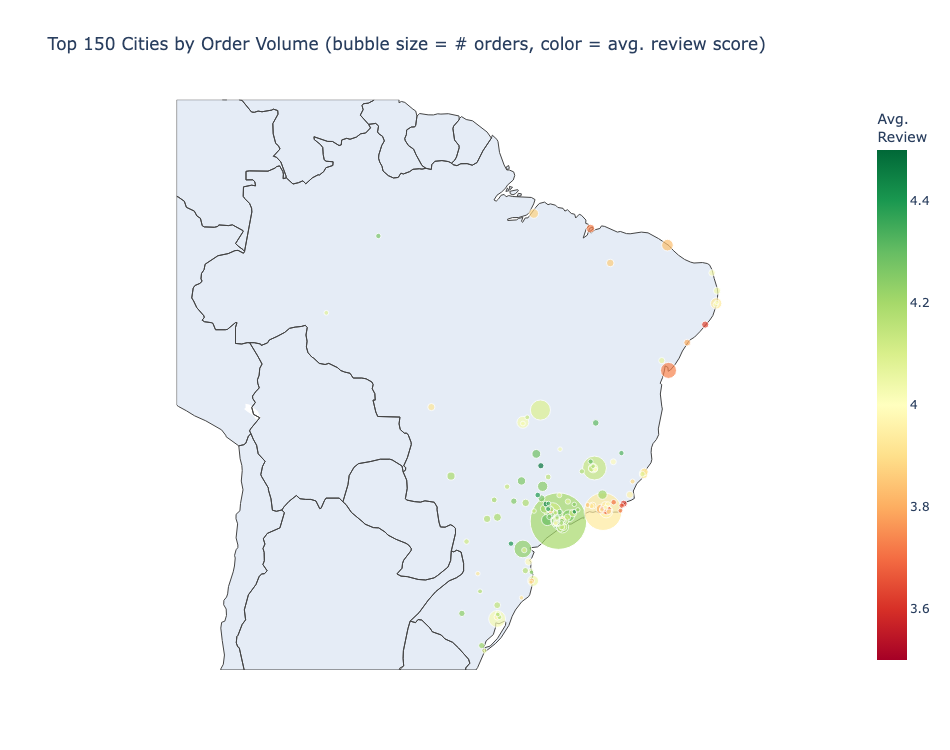

In [17]:
top_cities = city_demand.head(150).copy()

fig = px.scatter_geo(
    top_cities,
    lat="lat", lon="lon",
    size="n_orders",
    color="avg_review_score",
    color_continuous_scale="RdYlGn",
    range_color=[3.5, 4.5],
    hover_name="customer_city",
    hover_data={"customer_state": True, "n_orders": ":,", "gmv": ":,.0f",
                 "avg_review_score": ":.2f", "lat": False, "lon": False},
    scope="south america",
    size_max=40,
    title="Top 150 Cities by Order Volume (bubble size = # orders, color = avg. review score)",
)
fig.update_geos(lataxis_range=[-34, 6], lonaxis_range=[-75, -32])
fig.update_layout(width=950, height=750, coloraxis_colorbar=dict(title="Avg.<br>Review"))
fig.show()

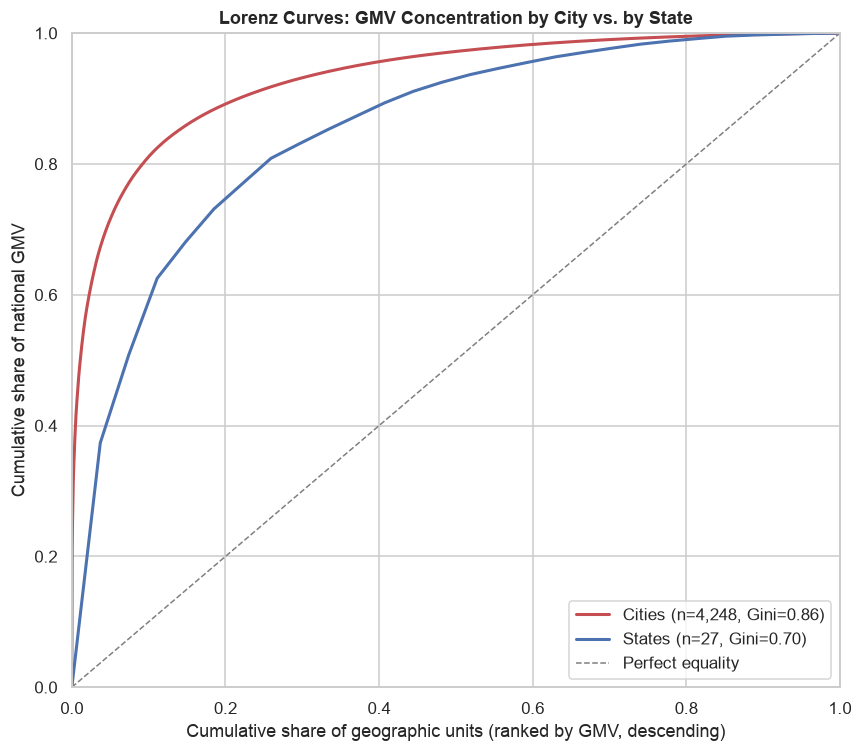

In [18]:
def lorenz_curve(values):
    v = np.sort(np.asarray(values, dtype=float))[::-1]  # descending
    cum = np.cumsum(v) / v.sum()
    x = np.arange(1, len(v) + 1) / len(v)
    return np.concatenate([[0], x]), np.concatenate([[0], cum])


fig, ax = plt.subplots(figsize=(8, 7))

for label, values, color in [("Cities (n=" + f"{len(city_demand):,}" + f", Gini={gini_city:.2f})", city_demand["gmv"], "#C44E52"),
                              ("States (n=" + f"{len(state_demand):,}" + f", Gini={gini_state:.2f})", state_demand["gmv"], "#4C72B0")]:
    x, y = lorenz_curve(values)
    ax.plot(x, y, label=label, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Perfect equality")
ax.set_xlabel("Cumulative share of geographic units (ranked by GMV, descending)")
ax.set_ylabel("Cumulative share of national GMV")
ax.set_title("Lorenz Curves: GMV Concentration by City vs. by State")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Finding: concentration intensifies sharply as the geographic unit gets smaller — the city-level Gini is far higher than the state-level Gini

- **São Paulo (the city) alone generates ~13.7% of national GMV** (15,291 orders) — more
  than the bottom ~20 *states combined*. Rio de Janeiro city adds another ~7.3%.
- **The top 100 cities (out of 4,248 — just 2.4% of all cities) generate 60% of national
  GMV**; the top 20 cities alone already pass 40%.
- The **Gini coefficient for city-level GMV is substantially higher than for state-level
  GMV** (visualized via the Lorenz curves above — the city curve bows much further from the
  equality line). This is the expected signature of a **spatial Zipf/power-law
  distribution**: aggregating into larger units (cities → states) mechanically smooths out
  inequality, so *the true concentration of demand is understated by state-level analysis
  alone*.
- **Operational read:** decisions like fulfillment-center siting or last-mile-carrier
  contracts are made at the city/metro level, not the state level. Sections 1-5 (state-level)
  correctly identify *which regions* are underserved — but a real network-design exercise
  would start from this city-level view, where a handful of metro areas (São Paulo, Rio,
  Belo Horizonte, Brasília, Curitiba — all visible as the largest bubbles on the map above)
  already account for the majority of volume, and the long tail of 4,000+ small cities is
  exactly where the cross-state, long-distance, high-`pct_late` orders from Sections 2 and 4
  are concentrated.

## 7. Key Findings Summary

Continuing the numbering from Notebooks 1-2 (findings 1-22):

| # | Finding | Evidence | Cross-reference |
|---|---|---|---|
| 23 | **Customer demand is heavily concentrated in the Southeast/South**: SP alone = 37.4% of GMV / 41.8% of customers; the top 5 states (SP, RJ, MG, RS, PR) = 73.1% of GMV; 8 states reach ~80%. The remaining 19 states (most of the North/Northeast) split the last ~20%. | Section 1 | Demand-side mirror of seller-concentration Q4.2 |
| 24 | **Late-delivery rate (`pct_late`) varies 8x by state** (2.9% RO to 23.9% AL), with a clear Northeast cluster (AL, MA, PI, CE, SE, BA — all ≥14%) standing out from the Southeast/South core (SP, MG, PR all ≤6%). | Section 2 | Refines SQL Q3.4's state-level on-time delivery rates |
| 25 | **The SLA estimate's "buffer" thinness — not absolute delivery time — predicts `pct_late`** (r=0.72): the Northeast cluster has the thinnest buffers (-8 to -10 days) and highest `pct_late`, while the deep-North states (AC, AP, AM, RO) have the *longest absolute* delivery times (19-29 days) but the *lowest* `pct_late` (2.9-4.5%) because their estimates are even more generously padded (38-46 days). | Section 2 | New analysis |
| 26 | **`avg_review_score` correlates with `pct_late` (r=-0.79) far more strongly than with absolute delivery time (r=-0.53)** — satisfaction tracks promise-keeping, not speed. **RJ** is the highest-impact outlier: 2nd-largest market (13.5% of GMV, 12,540 reviews) with a below-median review score (3.90) driven by a `pct_late` more than double SP's. | Section 3 | New analysis |
| 27 | **Order-level distance-decay is monotonic across 8 distance buckets**: `avg_actual_delivery_days` rises 3.7x (5.7→21.2 days), freight share of order value rises 10.5%→18.5%, `pct_late` more than doubles (5.8%→13.7%), and `avg_review_score` declines every bucket (4.37→3.99). But `distance_km` vs `delivery_delay_days` correlation is weak (r=-0.07) — the SLA estimate already scales with distance. | Section 4 | New analysis (haversine, 98.2% coverage) |
| 28 | **64% of single-seller orders are fulfilled cross-state**, taking ~1.9x longer (15.2 vs 8.0 days) and costing ~75% more freight (R$26.56 vs R$15.18) than same-state orders — cross-state fulfillment is the *majority* case, not an edge case. | Section 4 | Extends SQL Q4.4 (same/cross-state freight) |
| 29 | **Seller supply is even more concentrated than demand**: SP supplies 64.6% of item revenue but consumes only 37.4% (self-sufficiency ratio 1.73, the dominant net exporter along with PR 1.83 and SC 1.20). RJ, MG, BA, GO, ES, DF are all net importers (ratio <0.7, some <0.25). **4 of 27 states have zero local sellers** — 100% import-dependent. This is the structural root cause of Findings 24, 25, 27, 28. | Section 5 | Extends SQL Q4.5 |
| 30 | **City-level concentration is far sharper than state-level** (Gini for city GMV > Gini for state GMV): São Paulo city alone = ~13.7% of national GMV; top 100 of 4,248 cities = 60% of GMV. State-level views understate true geographic concentration — network-design decisions should be made at city/metro granularity. | Section 6 | New analysis |

**Overall takeaway:** Sections 1-6 form a causal chain. Demand is concentrated in the
Southeast (F23), but **supply is *even more* concentrated** (F29) — so a majority of orders
ship cross-state (F28), and the resulting distance (F27) interacts with *state-specific SLA
buffer policy* (F25) to produce the observed late-delivery geography (F24), which in turn
measurably depresses satisfaction in the highest-volume affected market, RJ (F26). **Any
single one of these findings, viewed in isolation, would suggest a narrower fix (e.g. "pad
RJ's estimates more"). Viewed together, they point at the same root-cause lever: regional
seller/fulfillment-supply expansion outside the Southeast** — which would simultaneously
shorten distances (F27/F28), allow tighter and more *uniform* SLA buffers (F25), reduce
`pct_late` (F24), and lift review scores (F26) in exactly the markets — RJ, the Northeast,
GO/ES/DF — where the GMV at stake (F23) makes the ROI case strongest.